### ml_pipeline_hybrid.py

Research-grade end-to-end cross-validated comparison + hybrid/optimized algorithm extensions.

Generates:
 - Per-model cross-validated ROC/PR/confusion/classification-report
 - SHAP plots (if installed)
 - Combined ROC plot overlaying mean ROC of all models
 - GA/PSO wrappers for feature selection + model training
 - Optuna Bayesian tuning for SVM (if optuna installed)
Outputs:
 - PDF report
 - PNG plots
 - comparison CSV

Run: python ml_pipeline_hybrid.py


### Importing Libraies



#### Standard Libraries

In [31]:
import os
import sys
import time
import random
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")


#### Data & Numerical Libraries

In [32]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from numpy import interp

#### Visualization Libraries

In [33]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

#### Machine Learning: Core Sklearn

In [34]:
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    train_test_split
)
from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn import pipeline


####  ML Algorithms (Sklearn)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier
)

#### Optional ML Libraries (Try/Except)

In [36]:
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    from lightgbm import early_stopping, log_evaluation
    HAS_LGB = True
except Exception:
    HAS_LGB = False

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception:
    HAS_TF = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    import optuna
    HAS_OPTUNA = True
except Exception:
    HAS_OPTUNA = False


#### Others

In [37]:
import joblib
from collections import defaultdict

In [38]:
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Data Load

##### LSGT

In [39]:
input_data_dir = "Data"
Dataset = "LSGT"
disease_name = pd.read_csv(os.path.join(input_data_dir, 'disease_name.csv'),header=None)
snoRNA_name = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_name.csv'),header=None)

###### Big DataSet


In [40]:
SnoRNA_similarity = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_similarity.csv'))
known_association = pd.read_csv(os.path.join(input_data_dir, 'known_snoRNA_disease.csv'), header=None)
disease_similarity = pd.read_csv(os.path.join(input_data_dir, 'disease_similarity.csv'), header=None)


###### K

In [41]:
# SnoRNA_similarity = pd.read_csv(os.path.join(input_data_dir, 'IRS_matrix.csv'), header=None)
# known_association = pd.read_csv(os.path.join(input_data_dir, 'known_snoRNA_disease.csv'), header=None)
# disease_similarity = pd.read_csv(os.path.join(input_data_dir, 'IDS_matrix.csv'), header=None)


###### I

In [42]:
# SnoRNA_similarity = pd.read_csv(os.path.join(input_data_dir, 'KS_matrix.csv'), header=None)
# known_association = pd.read_csv(os.path.join(input_data_dir, 'known_snoRNA_disease.csv'), header=None)
# disease_similarity = pd.read_csv(os.path.join(input_data_dir, 'IDS_matrix.csv'), header=None)

##### PSnoD

In [43]:
# input_data_dir = "PSnoD"
# disease = pd.read_csv(os.path.join(input_data_dir, 'disease_sim_graph_filtered.csv'))
# snoRNA = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_4mer_similarity.csv'))
# relation = pd.read_csv(os.path.join(input_data_dir, 'relationship_matrix_filtered.csv'))

# len(disease), len(snoRNA), len(relation)

In [44]:
# disease_name = disease.iloc[:,0:1]
# snoRNA_name = snoRNA.iloc[:,0:1]
# SnoRNA_similarity = snoRNA.iloc[:,1:]
# known_association = relation.iloc[:, 1:].T
# disease_similarity = disease.iloc[:,1:]
# disease_name.shape , snoRNA_name.shape , SnoRNA_similarity.shape , known_association.shape , disease_similarity.shape

##### Shape

In [45]:
disease_name.shape , snoRNA_name.shape , SnoRNA_similarity.shape , known_association.shape , disease_similarity.shape

((112, 2), (335, 1), (335, 335), (335, 112), (112, 112))

#### Data preprocessing

##### List to Numpy

In [46]:
disease_semantic_similarity = np.zeros(disease_similarity.shape) 
snoRNA_functional_similarity = np.zeros(SnoRNA_similarity.shape) 
adjacency_matrix = np.zeros(known_association.shape) 

disease_semantic_similarity = disease_similarity.values
snoRNA_functional_similarity = SnoRNA_similarity.values
adjacency_matrix = known_association.values

In [47]:
adjacency_matrix.shape , disease_semantic_similarity.shape , snoRNA_functional_similarity.shape

((335, 112), (112, 112), (335, 335))

##### Separation and permutation

In [48]:
unknown = []
known = []
for x in range(known_association.shape[0]):
    for y in range(known_association.shape[1]):
        if adjacency_matrix[x, y] == 0:
            unknown.append((x, y))
        else:
            known.append((x, y))



In [49]:
len(unknown), len(known) 

(36510, 1010)

In [50]:
         
major = []
for z in range(len(unknown)):
    a = disease_semantic_similarity[unknown[z][1], :].tolist()
    b = snoRNA_functional_similarity[unknown[z][0], :].tolist()
    q = a + b
    major.append(q) 

In [51]:
len(unknown), len(known), len(major)

(36510, 1010, 36510)

##### Clustaring

In [52]:
n_clusters = 23
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(major)
labels = kmeans.labels_

disease_rna_tup = defaultdict(list)
for (rna, dis), label in zip(unknown, labels):
    disease_rna_tup[label].append((rna, dis))



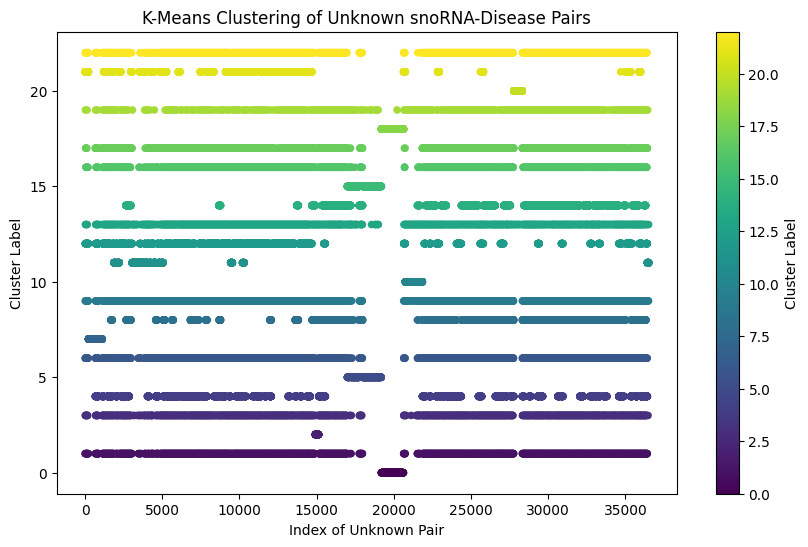

In [53]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(labels)), labels, c=labels, cmap='viridis', s=20)
plt.title('K-Means Clustering of Unknown snoRNA-Disease Pairs')
plt.xlabel('Index of Unknown Pair')
plt.ylabel('Cluster Label')
plt.colorbar(label='Cluster Label')
plt.show()

#### Final datasets are being prepared

In [54]:
sampled_disease_rna_tup = [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]
n = 0
for i in range(len(disease_rna_tup)):
    sampled_disease_rna_tup[i] = random.sample(disease_rna_tup[i], int((len(disease_rna_tup[i])/len(labels)) * len(known)))

dataset = []
for rna in range(known_association.shape[0]):
    for disease in range(known_association.shape[1]):
        for i in range(len(sampled_disease_rna_tup)):
            if (rna, disease) in sampled_disease_rna_tup[i]:
                dataset.append((rna, disease))


for rna in range(known_association.shape[0]):
    for disease in range(known_association.shape[1]):
        if (rna, disease) in known:
            dataset.append((rna, disease))

length = len(dataset)
print(length)


2007


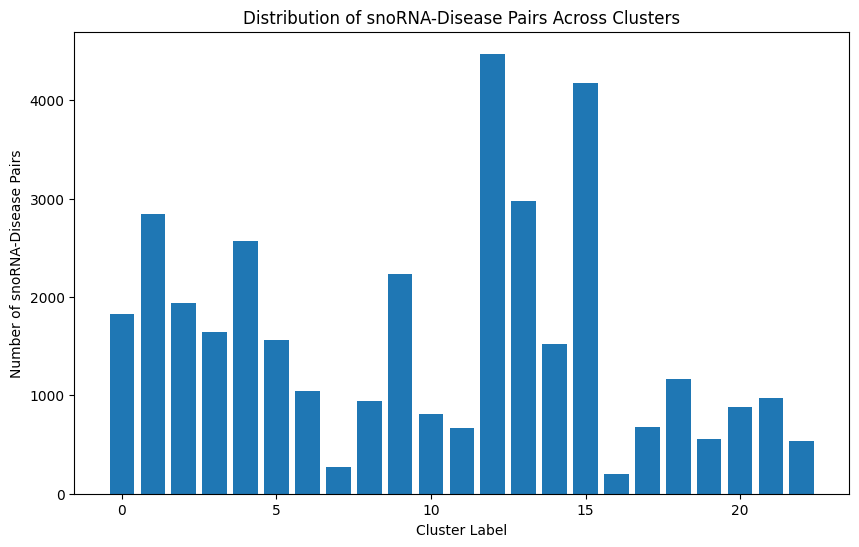

In [55]:
plt.figure(figsize=(10, 6))
plt.bar(range(n_clusters), [len(cluster) for cluster in disease_rna_tup.values()])
plt.xlabel('Cluster Label')
plt.ylabel('Number of snoRNA-Disease Pairs')
plt.title('Distribution of snoRNA-Disease Pairs Across Clusters')
plt.show()

In [56]:
selected_x = []
selected_y = []
#now I am just taking only the similarities of disease and rna of sampled data.
for data in dataset:
    a = disease_semantic_similarity[data[1], :].tolist()
    b = snoRNA_functional_similarity[data[0], :].tolist()
    q = a + b
    selected_x.append(q)

    if (data[0], data[1]) in known:
        selected_y.append(1)
    else:
        selected_y.append(0)

selected_data_np = np.array(selected_x)
selected_label_np = np.array(selected_y)


# Model

## Test

In [57]:



def evaluate_cv(model_name, model_builder, X, y, scale_for_nn=False, epochs=30, batch_size=32):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    mean_fpr = np.linspace(0, 1, 100)
    mean_recall = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    precisions = []
    scores = []
    roc_auc_scores = []
    y_true_all = []
    y_pred_all = []

    fold_idx = 0
    param_grid = {'SVM__C': [0.1, 1, 10, 100], 'SVM__gamma': [1, 0.1, 0.01, 0.001]}

    # Use GridSearchCV to find the optimal parameters
    grid = GridSearchCV(pipeline, param_grid, cv=5)

    for train_idx, test_idx in skf.split(X, y):
        fold_idx += 1
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # scale only for NN models or if specified
        if model_name == 'DNN' or scale_for_nn:
            scaler = StandardScaler(with_mean=False)
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
 

        # If model_builder returns an sklearn estimator:
        if hasattr(model_builder, '__call__') and model_name != 'DNN' and model_name not in ('xgboost', 'lightgbm_custom'):
            
            model = model_builder()
            model.fit(X_train, y_train)
            proba = model.predict_proba(X_test)[:, 1]
            pred = model.predict(X_test)
            # joblib.dump(model, os.path.join(OUTPUT_DIR, f"{model_name}_fold{fold_idx}.joblib"))
        else:
            if model_name == 'xgboost' and HAS_XGB:
                dtrain = xgb.DMatrix(X_train, label=y_train)
                dtest = xgb.DMatrix(X_test, label=y_test)
                params = {'objective':'binary:logistic', 'eval_metric':'auc', 'seed':42, 'verbosity':0}
                bst = xgb.train(params, dtrain, num_boost_round=100)
                proba = bst.predict(dtest)
                pred = (proba >= 0.5).astype(int)
                bst.save_model(os.path.join(OUTPUT_DIR, f"xgb_fold{fold_idx}.model"))
            elif model_name == 'lightgbm_custom' and HAS_LGB:
                lgb_train = lgb.Dataset(X_train, label=y_train)
                lgb_eval = lgb.Dataset(X_test, label=y_test, reference=lgb_train)
                params = {'objective': 'binary', 'metric': 'auc', 'verbose': -1, 'seed': 42}
                # gbm = lgb.train(params, lgb_train, num_boost_round=100, valid_sets=[lgb_eval], verbose_eval=False)
                gbm = lgb.train(
                            params,
                            lgb_train,
                            num_boost_round=100,
                            valid_sets=[lgb_eval],
                            callbacks=[
                                log_evaluation(period=0),       # disable logging (verbose_eval=False)
                                early_stopping(stopping_rounds=20)
    ]
)
                proba = gbm.predict(X_test)
                pred = (proba >= 0.5).astype(int)
                gbm.save_model(os.path.join(OUTPUT_DIR, f"lgb_fold{fold_idx}.txt"))
            elif model_name == 'DNN' and HAS_TF:
                # build small dense model
                tf.keras.backend.clear_session()
                inp = X_train.shape[1]
                model = keras.Sequential([
                    keras.layers.Input(shape=(inp,)),
                    keras.layers.Dense(256, activation='relu'),
                    keras.layers.Dropout(0.3),
                    keras.layers.Dense(128, activation='relu'),
                    keras.layers.Dropout(0.2),
                    keras.layers.Dense(1, activation='sigmoid')
                ])
                model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['AUC'])
                model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=0.1)
                proba = model.predict(X_test).ravel()
                pred = (proba >= 0.5).astype(int)
                model.save(os.path.join(OUTPUT_DIR, f"dnn_fold{fold_idx}.h5"))
            else:
                raise RuntimeError(f"Unsupported model or missing package for {model_name}.")
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        proba = best_model.predict_proba(X_test)[:, 1]
        pred = best_model.predict(X_test)
        joblib.dump(best_model, os.path.join(OUTPUT_DIR, f"{model_name}_fold{fold_idx}.joblib"))
        # metrics
        roc_auc = roc_auc_score(y_test, proba)
        roc_auc_scores.append(roc_auc)
        score = np.mean(pred == y_test)
        scores.append(score)

        fpr, tpr, _ = roc_curve(y_test, proba)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        aucs.append(auc(fpr, tpr))

        precision, recall, _ = precision_recall_curve(y_test, proba)
        precisions.append(np.interp(mean_recall, recall[::-1], precision[::-1]))

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(pred.tolist())

        print(f"[{model_name}] Fold {fold_idx} — ROC AUC: {roc_auc:.4f}, Accuracy: {score:.4f}")

    # finalize metrics and plotting
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    mean_precision = np.mean(precisions, axis=0)
    mean_auc_pr = auc(mean_recall, mean_precision)

    print(f"\n{model_name} Summary — Mean ROC AUC: {np.mean(roc_auc_scores):.4f} ± {np.std(roc_auc_scores):.4f}")
    print(f"{model_name} Summary — Mean AUPR: {mean_auc_pr:.4f}")

    # Plot ROC
    plt.figure(figsize=(7,5))
    plt.plot(mean_fpr, mean_tpr, lw=2, label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})")
    plt.plot([0,1], [0,1], linestyle='--', color='r')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title(f"ROC: {model_name}")
    plt.legend(); plt.show()

    # Plot PR
    plt.figure(figsize=(7,5))
    plt.plot(mean_recall, mean_precision, lw=2, label=f"Mean PR (AUPR={mean_auc_pr:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"Precision-Recall: {model_name}")
    plt.legend(); plt.show()

    # final f1 computed on last fold's y_test/pred for quick check (you can compute global f1 too)
    f1 = f1_score(y_test, pred)
    print(f"{model_name} final fold F1: {f1:.4f}")

    return {
        'mean_roc_auc': float(np.mean(roc_auc_scores)),
        'mean_aupr': float(mean_auc_pr),
        'last_model_name': model_name
    }



In [58]:



# ---------- Config ----------
OUTPUT_DIR = "master_pipeline_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SPLITS = 5
RANDOM_STATE = 42

# Model and Grid configs (tune as needed)
SVM_PARAM_GRID = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.1],
    "svm__kernel": ["rbf", "linear"]
}

RF_PARAMS = {'n_estimators': 200, 'random_state': RANDOM_STATE}
LOGISTIC_PARAMS = {'max_iter': 1000, 'solver': 'lbfgs'}
XGB_ROUNDS = 200
LGB_ROUNDS = 500
DNN_EPOCHS = 40
DNN_BATCH = 64

SAVE_MODELS = True
SAVE_PLOTS = True
PDF_REPORT_NAME = os.path.join(OUTPUT_DIR, f"ml_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
COMPARISON_CSV = os.path.join(OUTPUT_DIR, "model_comparison_table.csv")

# ---------- Helper functions ----------
def ensure_array(X):
    """Return numpy array if possible (keep sparse if sparse)."""
    try:
        if sp.issparse(X):
            return X
    except Exception:
        pass
    return np.asarray(X)

def build_dnn_model(input_dim):
    """Small Keras model."""
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def plot_confusion_matrix(cm, classes, title='Confusion matrix', figsize=(5,4)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

def plot_classification_text(report_text, title='Classification Report', figsize=(8,6)):
    plt.figure(figsize=figsize)
    plt.axis('off')
    plt.text(0, 1, title, fontsize=14, weight='bold')
    plt.text(0, 0.95, report_text, fontsize=9, family='monospace')
    plt.tight_layout()

def safe_save_fig(filename):
    try:
        plt.savefig(filename, bbox_inches='tight')
    except Exception as e:
        print("Failed to save figure:", e)

def save_model(obj, path):
    try:
        if hasattr(obj, 'save') and (path.endswith('.h5') or path.endswith('.hdf5')):
            obj.save(path)
        elif hasattr(obj, 'save_model') and path.endswith('.model'):
            obj.save_model(path)
        else:
            joblib.dump(obj, path)
    except Exception as e:
        print(f"Warning: could not save model to {path}: {e}")

# ---------- Main evaluation function ----------
def evaluate_and_report(X, y,
                        models_to_run=None,
                        n_splits=N_SPLITS,
                        random_state=RANDOM_STATE,
                        svm_param_grid=None,
                        save_models=SAVE_MODELS,
                        dnn_epochs=DNN_EPOCHS,
                        dnn_batch=DNN_BATCH):
    """
    Run cross-validated experiments for multiple models and produce plots, SHAP, and a PDF report.
    """
    X = ensure_array(X)
    y = np.asarray(y)

    if svm_param_grid is None:
        svm_param_grid = SVM_PARAM_GRID

    # default models
    available_models = ['logistic', 'rf', 'svm', 'xgboost', 'lightgbm', 'dnn']
    if models_to_run is None:
        models_to_run = available_models.copy()

    models_final = []
    for m in models_to_run:
        if m == 'xgboost' and not HAS_XGB:
            print("Skipping XGBoost — not installed.")
            continue
        if m == 'lightgbm' and not HAS_LGB:
            print("Skipping LightGBM — not installed.")
            continue
        if m == 'dnn' and not HAS_TF:
            print("Skipping DNN — TensorFlow not installed.")
            continue
        models_final.append(m)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    results_summary = []
    pdf_pages = PdfPages(PDF_REPORT_NAME)

    # Title page
    plt.figure(figsize=(11,8.5))
    plt.axis('off')
    title = "ML Models Comparison Report"
    meta = f"Generated: {datetime.now().isoformat()}\nDataset samples: {len(y)}\nModels: {', '.join(models_final)}\nStratifiedKFold: {n_splits} splits\nRandom seed: {random_state}"
    plt.text(0.5, 0.6, title, ha='center', va='center', fontsize=26, weight='bold')
    plt.text(0.5, 0.45, meta, ha='center', va='center', fontsize=10)
    plt.tight_layout()
    pdf_pages.savefig()
    plt.close()

    # For each model
    for model_name in models_final:
        print(f"\n===== Running: {model_name.upper()} =====")
        mean_fpr = np.linspace(0, 1, 200)
        mean_recall = np.linspace(0, 1, 200)

        fold_tprs = []
        fold_fprs = []
        fold_precisions = []
        fold_recalls = []

        roc_aucs = []
        aupr_values = []
        accs = []
        f1s = []

        # store last fold predictions for confusion matrix display
        last_y_test = None
        last_pred = None
        last_proba = None
        fold_idx = 0

        # For SHAP, accumulate per-model if possible
        shap_available_for_model = False
        shap_objects = []  # to hold model and data for later plotting (if safe)

        for train_idx, test_idx in skf.split(X, y):
            fold_idx += 1
            print(f"[{model_name}] Fold {fold_idx}/{n_splits} ...", end=' ')
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            need_scale = model_name in ('svm', 'logistic', 'dnn')
            if need_scale:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
            else:
                X_train_scaled, X_test_scaled = X_train, X_test

            # Train model
            if model_name == 'logistic':
                model = LogisticRegression(**LOGISTIC_PARAMS)
                model.fit(X_train_scaled, y_train)
                proba = model.predict_proba(X_test_scaled)[:, 1]
                pred = model.predict(X_test_scaled)

                if save_models:
                    save_model(model, os.path.join(OUTPUT_DIR, f"logistic_fold{fold_idx}.joblib"))

                # SHAP available for linear models via KernelExplainer or directly (but KernelExplainer is slow)
                if HAS_SHAP:
                    try:
                        expl = shap.LinearExplainer(model, X_train_scaled, feature_perturbation="interventional")
                        shap_objects.append(('linear', expl, X_test_scaled))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'rf':
                model = RandomForestClassifier(**RF_PARAMS)
                model.fit(X_train, y_train)
                proba = model.predict_proba(X_test)[:, 1]
                pred = model.predict(X_test)

                if save_models:
                    save_model(model, os.path.join(OUTPUT_DIR, f"rf_fold{fold_idx}.joblib"))

                if HAS_SHAP:
                    try:
                        expl = shap.TreeExplainer(model)
                        shap_objects.append(('tree', expl, X_test))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'svm':
                pipe = Pipeline([
                    ('scaler', StandardScaler()),
                    ('svm', SVC(probability=True, random_state=random_state))
                ])
                grid = GridSearchCV(pipe, svm_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=0)
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
                proba = best_model.predict_proba(X_test)[:, 1]
                pred = best_model.predict(X_test)

                if save_models:
                    save_model(best_model, os.path.join(OUTPUT_DIR, f"svm_grid_fold{fold_idx}.joblib"))

                # SHAP for SVM would require KernelExplainer -> heavy; skip unless user insists

            elif model_name == 'xgboost' and HAS_XGB:
                dtrain = xgb.DMatrix(X_train, label=y_train)
                dtest = xgb.DMatrix(X_test, label=y_test)
                params = {'objective': 'binary:logistic', 'eval_metric': 'auc', 'seed': random_state, 'verbosity': 0}
                bst = xgb.train(params, dtrain, num_boost_round=XGB_ROUNDS)
                proba = bst.predict(dtest)
                pred = (proba >= 0.5).astype(int)

                if save_models:
                    save_model(bst, os.path.join(OUTPUT_DIR, f"xgb_fold{fold_idx}.model"))

                if HAS_SHAP:
                    try:
                        expl = shap.Explainer(bst)
                        shap_objects.append(('xgb', expl, xgb.DMatrix(X_test)))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'lightgbm' and HAS_LGB:
                lgb_train = lgb.Dataset(X_train, label=y_train)
                lgb_eval = lgb.Dataset(X_test, label=y_test, reference=lgb_train)
                params = {'objective': 'binary', 'metric': 'auc', 'verbose': -1, 'seed': random_state}
                gbm = lgb.train(
                    params, lgb_train, num_boost_round=LGB_ROUNDS,
                    valid_sets=[lgb_eval], callbacks=[log_evaluation(period=0), early_stopping(stopping_rounds=30)]
                )
                proba = gbm.predict(X_test, num_iteration=gbm.best_iteration)
                pred = (proba >= 0.5).astype(int)

                if save_models:
                    save_model(gbm, os.path.join(OUTPUT_DIR, f"lgb_fold{fold_idx}.txt"))

                if HAS_SHAP:
                    try:
                        expl = shap.TreeExplainer(gbm)
                        shap_objects.append(('lgb', expl, X_test))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'dnn' and HAS_TF:
                tf.keras.backend.clear_session()
                inp = X_train.shape[1]
                dnn = build_dnn_model(inp)
                dnn.fit(X_train_scaled, y_train, epochs=dnn_epochs, batch_size=dnn_batch, verbose=0, validation_split=0.1)
                proba = dnn.predict(X_test_scaled).ravel()
                pred = (proba >= 0.5).astype(int)

                if save_models:
                    save_model(dnn, os.path.join(OUTPUT_DIR, f"dnn_fold{fold_idx}.h5"))

                # SHAP DeepExplainer/GradientExplainer may work but is heavy
                if HAS_SHAP:
                    try:
                        expl = shap.DeepExplainer(dnn, X_train_scaled[:min(100, X_train_scaled.shape[0])])
                        shap_objects.append(('dnn', expl, X_test_scaled))
                        shap_available_for_model = True
                    except Exception:
                        pass

            else:
                raise RuntimeError(f"Unsupported model or missing package: {model_name}")

            # gather metrics
            try:
                roc = roc_auc_score(y_test, proba)
            except Exception:
                roc = roc_auc_score(y_test, pred)
            roc_aucs.append(roc)
            acc = accuracy_score(y_test, pred)
            f1 = f1_score(y_test, pred, zero_division=0)
            accs.append(acc)
            f1s.append(f1)

            fpr, tpr, _ = roc_curve(y_test, proba)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            fold_tprs.append(interp_tpr)
            fold_fprs.append(mean_fpr)

            precision, recall, _ = precision_recall_curve(y_test, proba)
            recall_rev = recall[::-1]
            precision_rev = precision[::-1]
            interp_precision = np.interp(mean_recall, recall_rev, precision_rev)
            fold_precisions.append(interp_precision)
            fold_recalls.append(mean_recall)
            aupr_values.append(auc(recall, precision))

            # last fold store for confusion matrix
            last_y_test = y_test
            last_pred = pred
            last_proba = proba

            print(f"ROC AUC: {roc:.4f}, Acc: {acc:.4f}, F1: {f1:.4f}")

        # summarize metrics
        mean_tpr = np.mean(fold_tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_auc = np.std(roc_aucs)
        mean_precision = np.mean(fold_precisions, axis=0)
        mean_aupr = auc(mean_recall, mean_precision)

        # Plot ROC
        plt.figure(figsize=(8,6))
        for fpr, tpr in zip(fold_fprs, fold_tprs):
            plt.plot(fpr, tpr, color='gray', lw=1, alpha=0.25)
        plt.plot(mean_fpr, mean_tpr, lw=2, label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})")
        plt.plot([0,1],[0,1], linestyle='--')
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC - {model_name.upper()}")
        plt.legend()
        plt.grid(True)
        roc_fig_path = os.path.join(OUTPUT_DIR, f"{model_name}_roc.png")
        if SAVE_PLOTS:
            plt.savefig(roc_fig_path, bbox_inches='tight')
        pdf_pages.savefig()
        plt.close()

        # Plot PR
        plt.figure(figsize=(8,6))
        for r, p in zip(fold_recalls, fold_precisions):
            plt.plot(r, p, color='gray', lw=1, alpha=0.25)
        plt.plot(mean_recall, mean_precision, lw=2, label=f"Mean PR (AUPR={mean_aupr:.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title(f"Precision-Recall - {model_name.upper()}")
        plt.legend()
        plt.grid(True)
        pr_fig_path = os.path.join(OUTPUT_DIR, f"{model_name}_pr.png")
        if SAVE_PLOTS:
            plt.savefig(pr_fig_path, bbox_inches='tight')
        pdf_pages.savefig()
        plt.close()

        # Confusion matrix + classification report (from last fold)
        if last_y_test is not None and last_pred is not None:
            cm = confusion_matrix(last_y_test, last_pred)
            plot_confusion_matrix(cm, classes=['0','1'], title=f'Confusion Matrix - {model_name.upper()} (last fold)')
            cm_path = os.path.join(OUTPUT_DIR, f"{model_name}_confusion.png")
            if SAVE_PLOTS:
                plt.savefig(cm_path, bbox_inches='tight')
            pdf_pages.savefig()
            plt.close()

            cls_report = classification_report(last_y_test, last_pred, zero_division=0)
            plot_classification_text(cls_report, title=f'Classification Report - {model_name.upper()} (last fold)')
            rpt_path = os.path.join(OUTPUT_DIR, f"{model_name}_classification_report.png")
            if SAVE_PLOTS:
                plt.savefig(rpt_path, bbox_inches='tight')
            pdf_pages.savefig()
            plt.close()
        else:
            cls_report = "Not available"

        # SHAP plots if available
        shap_paths = []
        if HAS_SHAP and shap_available_for_model and len(shap_objects) > 0:
            # Try to create a SHAP summary figure for the first explainer
            try:
                # NOTE: shap.summary_plot writes to current matplotlib figure if show=False in recent SHAP versions
                expl_type, expl, sample_data = shap_objects[0]
                plt.figure(figsize=(8,6))
                try:
                    # For TreeExplainer / Explainer: shap.summary_plot accepts raw matrix and expl outputs
                    shap.summary_plot(expl, sample_data, show=False)
                except TypeError:
                    # Older shap call
                    shap.summary_plot(sample_data, expl, show=False)
                shap_path = os.path.join(OUTPUT_DIR, f"{model_name}_shap_summary.png")
                plt.tight_layout()
                if SAVE_PLOTS:
                    plt.savefig(shap_path, bbox_inches='tight')
                pdf_pages.savefig()
                plt.close()
                shap_paths.append(shap_path)
            except Exception as e:
                print("SHAP plotting failed for", model_name, e)

        # Save summary metrics for this model
        results_summary.append({
            'model': model_name,
            'mean_roc_auc': float(np.mean(roc_aucs)),
            'std_roc_auc': float(np.std(roc_aucs)),
            'mean_aupr': float(np.mean(aupr_values)),
            'mean_accuracy': float(np.mean(accs)),
            'mean_f1': float(np.mean(f1s))
        })

    # comparison table
    df = pd.DataFrame(results_summary).sort_values(by='mean_roc_auc', ascending=False).reset_index(drop=True)
    df.to_csv(COMPARISON_CSV, index=False)
    print("\n=== Comparison Table ===")
    print(df)

    # Append comparison table to PDF (as a text page)
    plt.figure(figsize=(11,8.5))
    plt.axis('off')
    plt.text(0.02, 0.98, "Model Comparison Table (sorted by mean ROC AUC)", fontsize=14, weight='bold', va='top')
    table_txt = df.to_string(index=False)
    plt.text(0.02, 0.92, table_txt, fontsize=8, family='monospace', va='top')
    pdf_pages.savefig()
    plt.close()

    pdf_pages.close()
    print(f"\nPDF report saved to: {PDF_REPORT_NAME}")
    print(f"Comparison CSV saved to: {COMPARISON_CSV}")
    return df

# ---------- Example usage ----------
if __name__ == "__main__":
    # This part is an example. Replace with your data loading.
    # Example: load a small dataset if run as script for quick smoke test
    # ---------------------- Synthetic Data Generation ----------------------
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=100, n_features=20, n_informative=8,
                               n_redundant=2, random_state=RANDOM_STATE, weights=[0.7,0.3])

    # Run everything
    df = evaluate_and_report(X, y)
    print("\nDone. Top models:")
    print(df.head())



===== Running: LOGISTIC =====
[logistic] Fold 1/5 ... ROC AUC: 0.7976, Acc: 0.7500, F1: 0.6667
[logistic] Fold 2/5 ... ROC AUC: 0.6429, Acc: 0.7000, F1: 0.4000
[logistic] Fold 3/5 ... ROC AUC: 0.7262, Acc: 0.7000, F1: 0.5000
[logistic] Fold 4/5 ... ROC AUC: 0.5833, Acc: 0.8000, F1: 0.5000
[logistic] Fold 5/5 ... ROC AUC: 0.8901, Acc: 0.7500, F1: 0.5455
SHAP plotting failed for logistic 'LinearExplainer' object has no attribute 'shape'

===== Running: RF =====
[rf] Fold 1/5 ... ROC AUC: 0.7976, Acc: 0.8500, F1: 0.6667
[rf] Fold 2/5 ... ROC AUC: 0.4048, Acc: 0.7500, F1: 0.4444
[rf] Fold 3/5 ... ROC AUC: 0.7024, Acc: 0.6500, F1: 0.3636
[rf] Fold 4/5 ... ROC AUC: 0.7500, Acc: 0.7500, F1: 0.2857
[rf] Fold 5/5 ... ROC AUC: 0.8022, Acc: 0.8000, F1: 0.6000
SHAP plotting failed for rf 'TreeExplainer' object has no attribute 'shape'

===== Running: SVM =====
[svm] Fold 1/5 ... ROC AUC: 0.7381, Acc: 0.7000, F1: 0.0000
[svm] Fold 2/5 ... ROC AUC: 0.5476, Acc: 0.7000, F1: 0.4000
[svm] Fold 3/5 ...

ROC AUC: 0.7381, Acc: 0.6500, F1: 0.5333
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


ROC AUC: 0.5952, Acc: 0.6500, F1: 0.3636
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


ROC AUC: 0.7738, Acc: 0.6500, F1: 0.4615
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


ROC AUC: 0.6071, Acc: 0.8500, F1: 0.6667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [ ]:


# ---------- Config ----------
OUTPUT_DIR = "master_pipeline_hybrid_output_"+Dataset
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SPLITS = 5
RANDOM_STATE = 42

SVM_PARAM_GRID = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", 0.1],
    "clf__kernel": ["rbf", "linear"]
}

RF_PARAMS = {'n_estimators': 200, 'random_state': RANDOM_STATE}
LOGISTIC_PARAMS = {'max_iter': 1000, 'solver': 'lbfgs'}
XGB_ROUNDS = 200
LGB_ROUNDS = 500
DNN_EPOCHS = 40
DNN_BATCH = 64

SAVE_MODELS = True
SAVE_PLOTS = True
PDF_REPORT_NAME = os.path.join(OUTPUT_DIR, f"ml_hybrid_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf")
COMPARISON_CSV = os.path.join(OUTPUT_DIR, "model_comparison_table_hybrid.csv")

# ---------- Utilities ----------
def ensure_array(X):
    try:
        if sp.issparse(X):
            return X
    except Exception:
        pass
    return np.asarray(X)

def build_dnn_model(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def plot_confusion_matrix(cm, classes, title='Confusion matrix', figsize=(5,4)):
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(int(cm[i, j]), 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

def plot_classification_text(report_text, title='Classification Report', figsize=(8,6)):
    plt.figure(figsize=figsize)
    plt.axis('off')
    plt.text(0, 1, title, fontsize=14, weight='bold')
    plt.text(0, 0.95, report_text, fontsize=9, family='monospace')
    plt.tight_layout()

def save_model(obj, path):
    try:
        if hasattr(obj, 'save') and (path.endswith('.h5') or path.endswith('.hdf5')):
            obj.save(path)
        else:
            joblib.dump(obj, path)
    except Exception as e:
        print(f"Warning: could not save model to {path}: {e}")

# ---------- Simple GA for feature selection (no external deps) ----------
def ga_feature_selection(X, y, estimator_builder, n_generations=15, pop_size=20, crossover_rate=0.8, mutation_rate=0.02, random_state=RANDOM_STATE):
    """
    Binary GA: chromosome bits indicate whether feature is selected.
    estimator_builder: callable -> returns a fresh estimator (must have fit/predict_proba)
    Returns: best_mask (boolean array)
    """
    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    def random_individual():
        # ensure at least one feature
        mask = rng.rand(n_features) < 0.5
        if not mask.any():
            mask[rng.randint(n_features)] = True
        return mask

    def fitness(mask):
        # evaluate by cross-validated ROC AUC (quick 3-fold)
        if mask.sum() == 0:
            return 0.0
        Xm = X[:, mask]
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr, te in skf.split(Xm, y):
            est = estimator_builder()
            try:
                est.fit(Xm[tr], y[tr])
                proba = est.predict_proba(Xm[te])[:, 1]
                scores.append(roc_auc_score(y[te], proba))
            except Exception:
                # fallback to predict
                try:
                    pred = est.fit(Xm[tr], y[tr]).predict(Xm[te])
                    scores.append(roc_auc_score(y[te], pred))
                except Exception:
                    scores.append(0.0)
        return float(np.mean(scores))

    # init population
    pop = [random_individual() for _ in range(pop_size)]
    pop_fitness = [fitness(ind) for ind in pop]

    for gen in range(n_generations):
        # sort by fitness descending
        idxs = np.argsort(pop_fitness)[::-1]
        pop = [pop[i] for i in idxs]
        pop_fitness = [pop_fitness[i] for i in idxs]
        # elitism: keep top 2
        new_pop = pop[:2]
        while len(new_pop) < pop_size:
            # selection (tournament)
            a, b = rng.randint(pop_size), rng.randint(pop_size)
            parent1 = pop[a] if pop_fitness[a] > pop_fitness[b] else pop[b]
            a, b = rng.randint(pop_size), rng.randint(pop_size)
            parent2 = pop[a] if pop_fitness[a] > pop_fitness[b] else pop[b]
            # crossover
            if rng.rand() < crossover_rate:
                cx_point = rng.randint(1, n_features-1)
                child = np.concatenate([parent1[:cx_point], parent2[cx_point:]]).astype(bool)
            else:
                child = parent1.copy()
            # mutation
            for i in range(n_features):
                if rng.rand() < mutation_rate:
                    child[i] = not child[i]
            if not child.any():
                child[rng.randint(n_features)] = True
            new_pop.append(child)
        pop = new_pop
        pop_fitness = [fitness(ind) for ind in pop]
        # debug
        best_idx = int(np.argmax(pop_fitness))
        print(f"[GA] Gen {gen+1}/{n_generations} best fitness: {pop_fitness[best_idx]:.4f} selected {pop[best_idx].sum()} features")
    best_mask = pop[int(np.argmax(pop_fitness))]
    return best_mask

# ---------- Simple PSO for feature selection (continuous weights -> threshold) ----------
def pso_feature_selection(X, y, estimator_builder, n_particles=20, iters=20, w=0.72, c1=1.49, c2=1.49, random_state=RANDOM_STATE):
    """
    Simple PSO: each particle is a vector of continuous weights in [0,1]; threshold to select features
    Returns: best_mask boolean array
    """
    rng = np.random.RandomState(random_state)
    n_features = X.shape[1]

    def fitness_from_weights(wvec):
        mask = wvec > 0.5
        if mask.sum() == 0:
            return 0.0
        Xm = X[:, mask]
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr, te in skf.split(Xm, y):
            est = estimator_builder()
            try:
                est.fit(Xm[tr], y[tr])
                proba = est.predict_proba(Xm[te])[:, 1]
                scores.append(roc_auc_score(y[te], proba))
            except Exception:
                try:
                    pred = est.fit(Xm[tr], y[tr]).predict(Xm[te])
                    scores.append(roc_auc_score(y[te], pred))
                except Exception:
                    scores.append(0.0)
        return float(np.mean(scores))

    # initialize
    particles = [rng.rand(n_features) for _ in range(n_particles)]
    velocities = [rng.normal(scale=0.1, size=n_features) for _ in range(n_particles)]
    pbest = particles.copy()
    pbest_scores = [fitness_from_weights(p) for p in particles]
    gbest_idx = int(np.argmax(pbest_scores))
    gbest = pbest[gbest_idx].copy()
    gbest_score = pbest_scores[gbest_idx]
    for it in range(iters):
        for i in range(n_particles):
            r1 = rng.rand(n_features)
            r2 = rng.rand(n_features)
            velocities[i] = w*velocities[i] + c1*r1*(pbest[i]-particles[i]) + c2*r2*(gbest-particles[i])
            particles[i] = particles[i] + velocities[i]
            # clamp to [0,1]
            particles[i] = np.clip(particles[i], 0.0, 1.0)
            score = fitness_from_weights(particles[i])
            if score > pbest_scores[i]:
                pbest[i] = particles[i].copy()
                pbest_scores[i] = score
                if score > gbest_score:
                    gbest = pbest[i].copy()
                    gbest_score = score
        print(f"[PSO] Iter {it+1}/{iters} gbest_score: {gbest_score:.4f}")
    best_mask = gbest > 0.5
    if not best_mask.any():
        # pick top-1 weight
        best_mask[np.argmax(gbest)] = True
    return best_mask

# ---------- Bayes optimization for SVM using Optuna ----------
def optuna_tune_svm(X, y, n_trials=30, random_state=RANDOM_STATE):
    if not HAS_OPTUNA:
        raise RuntimeError("Optuna not installed.")
    def objective(trial):
        C = trial.suggest_loguniform('C', 1e-3, 1e2)
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto', 0.1, 1, 10])
        kernel = trial.suggest_categorical('kernel', ['rbf', 'linear'])
        clf = SVC(C=C, gamma=gamma, kernel=kernel, probability=True, random_state=random_state)
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []
        for tr, te in skf.split(X, y):
            clf.fit(X[tr], y[tr])
            try:
                proba = clf.predict_proba(X[te])[:,1]
                scores.append(roc_auc_score(y[te], proba))
            except Exception:
                scores.append(roc_auc_score(y[te], clf.predict(X[te])))
        return np.mean(scores)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials)
    return study.best_params

# ---------- Evaluate & report (extended) ----------
def evaluate_and_report(X, y, models_to_run=None, n_splits=N_SPLITS, random_state=RANDOM_STATE, svm_param_grid=None, save_models=SAVE_MODELS, dnn_epochs=DNN_EPOCHS):
    X = ensure_array(X)
    y = np.asarray(y)
    if svm_param_grid is None:
        svm_param_grid = SVM_PARAM_GRID

    # incoming model list if None
    available_models = ['logistic','rf','svm','xgb','lgb','dnn','stacking','voting','bagging','pca_svm','ga_xgb','pso_svm','bayes_opt_svms']
    if models_to_run is None:
        models_to_run = available_models.copy()
    # filter by availability
    models_final = []
    for m in models_to_run:
        if m == 'xgb' and not HAS_XGB:
            print("Skipping xgb (xgboost not installed).")
            continue
        if m == 'lgb' and not HAS_LGB:
            print("Skipping lgb (lightgbm not installed).")
            continue
        if m == 'dnn' and not HAS_TF:
            print("Skipping dnn (tensorflow not installed).")
            continue
        if m == 'bayes_opt_svms' and not HAS_OPTUNA:
            print("Skipping bayes_opt_svms (optuna not installed).")
            continue
        models_final.append(m)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results_summary = []
    pdf_pages = PdfPages(PDF_REPORT_NAME)

    # Title page
    plt.figure(figsize=(11,8.5)); plt.axis('off')
    title = "ML Hybrid Models Comparison Report"
    meta = f"Generated: {datetime.now().isoformat()}\nDataset samples: {len(y)}\nModels: {', '.join(models_final)}\nStratifiedKFold: {n_splits} splits\nRandom seed: {random_state}"
    plt.text(0.5, 0.6, title, ha='center', va='center', fontsize=26, weight='bold')
    plt.text(0.5, 0.45, meta, ha='center', va='center', fontsize=10)
    plt.tight_layout(); pdf_pages.savefig(); plt.close()

    # hold mean ROC data for combined plot
    combined_rocs = {}  # model_name -> (mean_fpr, mean_tpr, mean_auc, std_auc)

    for model_name in models_final:
        print(f"\n===== Running: {model_name.upper()} =====")
        mean_fpr = np.linspace(0,1,200)
        fold_tprs = []
        fold_fprs = []
        fold_precisions = []
        fold_recalls = []
        roc_aucs = []
        aupr_values = []
        accs = []
        f1s = []
        last_y_test = None; last_pred = None; last_proba = None
        fold_idx = 0
        shap_objects = []
        shap_available_for_model = False

        # If model requires pre-selection (GA/PSO) we'll compute mask per outer fold
        for train_idx, test_idx in skf.split(X,y):
            fold_idx += 1
            print(f"[{model_name}] Fold {fold_idx}/{n_splits} ...", end=' ')
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # default scaling for some models
            need_scale = model_name in ('svm','logistic','dnn','pca_svm','pso_svm')
            scaler = None
            if need_scale:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
            else:
                X_train_scaled, X_test_scaled = X_train, X_test

            # define helper to save model
            def _save(obj, name):
                if save_models:
                    path = os.path.join(OUTPUT_DIR, name)
                    save_model(obj, path)

            # Build/train models per type
            if model_name == 'logistic':
                model = LogisticRegression(**LOGISTIC_PARAMS)
                model.fit(X_train_scaled, y_train)
                proba = model.predict_proba(X_test_scaled)[:,1]
                pred = model.predict(X_test_scaled)
                _save(model, f"logistic_fold{fold_idx}.joblib")
                if HAS_SHAP:
                    try:
                        expl = shap.LinearExplainer(model, X_train_scaled, feature_perturbation="interventional")
                        shap_objects.append(('linear', expl, X_test_scaled))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'rf':
                model = RandomForestClassifier(**RF_PARAMS)
                model.fit(X_train, y_train)
                proba = model.predict_proba(X_test)[:,1]
                pred = model.predict(X_test)
                _save(model, f"rf_fold{fold_idx}.joblib")
                if HAS_SHAP:
                    try:
                        expl = shap.TreeExplainer(model)
                        shap_objects.append(('tree', expl, X_test))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'svm':
                pipe = Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=random_state))])
                grid = GridSearchCV(pipe, svm_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=0)
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
                proba = best_model.predict_proba(X_test)[:,1]
                pred = best_model.predict(X_test)
                _save(best_model, f"svm_grid_fold{fold_idx}.joblib")

            elif model_name == 'xgb' and HAS_XGB:
                dtrain = xgb.DMatrix(X_train, label=y_train)
                dtest = xgb.DMatrix(X_test, label=y_test)
                params = {'objective':'binary:logistic','eval_metric':'auc','seed':random_state,'verbosity':0}
                bst = xgb.train(params, dtrain, num_boost_round=XGB_ROUNDS)
                proba = bst.predict(dtest)
                pred = (proba >= 0.5).astype(int)
                _save(bst, f"xgb_fold{fold_idx}.model")
                if HAS_SHAP:
                    try:
                        expl = shap.Explainer(bst)
                        shap_objects.append(('xgb', expl, xgb.DMatrix(X_test)))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'lgb' and HAS_LGB:
                lgb_train = lgb.Dataset(X_train, label=y_train)
                lgb_eval = lgb.Dataset(X_test, label=y_test, reference=lgb_train)
                params = {'objective':'binary','metric':'auc','verbose':-1,'seed':random_state}
                gbm = lgb.train(params, lgb_train, num_boost_round=LGB_ROUNDS, valid_sets=[lgb_eval], callbacks=[log_evaluation(period=0), early_stopping(stopping_rounds=30)])
                proba = gbm.predict(X_test, num_iteration=gbm.best_iteration)
                pred = (proba >= 0.5).astype(int)
                _save(gbm, f"lgb_fold{fold_idx}.txt")
                if HAS_SHAP:
                    try:
                        expl = shap.TreeExplainer(gbm)
                        shap_objects.append(('lgb', expl, X_test))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'dnn' and HAS_TF:
                tf.keras.backend.clear_session()
                inp = X_train.shape[1]
                dnn = build_dnn_model(inp)
                dnn.fit(X_train_scaled, y_train, epochs=dnn_epochs, batch_size=DNN_BATCH, verbose=0, validation_split=0.1)
                proba = dnn.predict(X_test_scaled).ravel()
                pred = (proba >= 0.5).astype(int)
                _save(dnn, f"dnn_fold{fold_idx}.h5")
                if HAS_SHAP:
                    try:
                        expl = shap.DeepExplainer(dnn, X_train_scaled[:min(100, X_train_scaled.shape[0])])
                        shap_objects.append(('dnn', expl, X_test_scaled))
                        shap_available_for_model = True
                    except Exception:
                        pass

            elif model_name == 'stacking':
                # base estimators
                estimators = [
                    ('lr', LogisticRegression(**LOGISTIC_PARAMS)),
                    ('rf', RandomForestClassifier(**RF_PARAMS)),
                ]
                if HAS_XGB:
                    estimators.append(('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)))
                # meta-classifier
                meta = LogisticRegression(**LOGISTIC_PARAMS)
                stack = StackingClassifier(estimators=estimators, final_estimator=meta, cv=3, n_jobs=-1, passthrough=False)
                stack.fit(X_train, y_train)
                try:
                    proba = stack.predict_proba(X_test)[:,1]
                except Exception:
                    proba = stack.predict(X_test)
                pred = stack.predict(X_test)
                _save(stack, f"stacking_fold{fold_idx}.joblib")

            elif model_name == 'voting':
                # soft voting across a few models
                members = []
                members.append(('lr', LogisticRegression(**LOGISTIC_PARAMS)))
                members.append(('rf', RandomForestClassifier(**RF_PARAMS)))
                if HAS_XGB:
                    members.append(('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)))
                voting = VotingClassifier(estimators=members, voting='soft', n_jobs=-1)
                voting.fit(X_train, y_train)
                proba = voting.predict_proba(X_test)[:,1]
                pred = voting.predict(X_test)
                _save(voting, f"voting_fold{fold_idx}.joblib")

            elif model_name == 'bagging':
                base = LogisticRegression(**LOGISTIC_PARAMS)
                bag = BaggingClassifier(estimator=base,n_estimators=10,random_state=random_state,n_jobs=-1)

                bag.fit(X_train, y_train)
                proba = bag.predict_proba(X_test)[:,1]
                pred = bag.predict(X_test)
                _save(bag, f"bagging_fold{fold_idx}.joblib")

            elif model_name == 'pca_svm':
                pipe = Pipeline([('pca', PCA(n_components=min(20, X_train.shape[1]))), ('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=random_state))])
                grid = GridSearchCV(pipe, {'clf__C':[0.1,1,10],'clf__kernel':['rbf','linear']}, scoring='roc_auc', cv=3, n_jobs=-1)
                grid.fit(X_train, y_train)
                best = grid.best_estimator_
                proba = best.predict_proba(X_test)[:,1]
                pred = best.predict(X_test)
                _save(best, f"pca_svm_fold{fold_idx}.joblib")

            elif model_name == 'ga_xgb':
                if not HAS_XGB:
                    print("Skipping ga_xgb for this fold (xgboost missing).")
                    proba = np.zeros(len(y_test))
                    pred = np.zeros(len(y_test))
                else:
                    # use GA to select features (small generations for speed)
                    def builder():
                        return xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, n_estimators=50)
                    mask = ga_feature_selection(X_train, y_train, estimator_builder=builder, n_generations=8, pop_size=12)
                    print(f"[ga_xgb] selected {mask.sum()} features")
                    Xtr = X_train[:, mask]; Xte = X_test[:, mask]
                    clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, n_estimators=100)
                    clf.fit(Xtr, y_train)
                    try:
                        proba = clf.predict_proba(Xte)[:,1]
                    except Exception:
                        proba = clf.predict(Xte)
                    pred = (proba >= 0.5).astype(int)
                    _save(clf, f"ga_xgb_fold{fold_idx}.joblib")

            elif model_name == 'pso_svm':
                # PSO to select features + SVM
                def builder():
                    return SVC(probability=True, random_state=random_state)
                mask = pso_feature_selection(X_train, y_train, estimator_builder=builder, n_particles=12, iters=10)
                print(f"[pso_svm] selected {mask.sum()} features")
                Xtr = X_train[:, mask]; Xte = X_test[:, mask]
                scaler2 = StandardScaler()
                Xtr_s = scaler2.fit_transform(Xtr); Xte_s = scaler2.transform(Xte)
                grid = GridSearchCV(SVC(probability=True, random_state=random_state), {'C':[0.1,1,10],'kernel':['rbf','linear']}, scoring='roc_auc', cv=3, n_jobs=-1)
                grid.fit(Xtr_s, y_train)
                best = grid.best_estimator_
                proba = best.predict_proba(Xte_s)[:,1]
                pred = best.predict(Xte_s)
                _save(best, f"pso_svm_fold{fold_idx}.joblib")

            elif model_name == 'bayes_opt_svms':
                # Use Optuna to tune SVM on the training fold, then evaluate on test fold
                best_params = optuna_tune_svm(X_train, y_train, n_trials=20, random_state=random_state)
                clf = SVC(C=best_params['C'], gamma=best_params['gamma'], kernel=best_params['kernel'], probability=True, random_state=random_state)
                scaler2 = StandardScaler()
                Xtr_s = scaler2.fit_transform(X_train); Xte_s = scaler2.transform(X_test)
                clf.fit(Xtr_s, y_train)
                proba = clf.predict_proba(Xte_s)[:,1]
                pred = clf.predict(Xte_s)
                _save(clf, f"bayes_opt_svm_fold{fold_idx}.joblib")

            else:
                raise RuntimeError(f"Unknown model: {model_name}")

            # compute metrics
            try:
                roc = roc_auc_score(y_test, proba)
            except Exception:
                roc = roc_auc_score(y_test, pred)
            roc_aucs.append(roc)
            accs.append(accuracy_score(y_test, pred))
            f1s.append(f1_score(y_test, pred, zero_division=0))

            fpr, tpr, _ = roc_curve(y_test, proba)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            fold_tprs.append(interp_tpr)
            fold_fprs.append(mean_fpr)

            precision, recall, _ = precision_recall_curve(y_test, proba)
            recall_rev = recall[::-1]; precision_rev = precision[::-1]
            interp_precision = np.interp(mean_fpr, recall_rev, precision_rev)  # reuse same grid
            fold_precisions.append(interp_precision)
            fold_recalls.append(mean_fpr)
            aupr_values.append(auc(recall, precision))

            last_y_test = y_test; last_proba = proba; last_pred = pred

            print(f"ROC AUC: {roc:.4f}, Acc: {accs[-1]:.4f}, F1: {f1s[-1]:.4f}")

        # summarize
        mean_tpr = np.mean(fold_tprs, axis=0) if len(fold_tprs) else np.zeros_like(mean_fpr)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_auc = np.std(roc_aucs) if len(roc_aucs)>0 else 0.0
        mean_precision = np.mean(fold_precisions, axis=0) if len(fold_precisions) else np.zeros_like(mean_fpr)
        mean_aupr = auc(mean_fpr, mean_precision) if len(mean_precision)>0 else 0.0

        # ROC figure (per-model)
        plt.figure(figsize=(8,6))
        for fpr, tpr in zip(fold_fprs, fold_tprs):
            plt.plot(fpr, tpr, color='gray', lw=1, alpha=0.25)
        plt.plot(mean_fpr, mean_tpr, lw=2, label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})")
        plt.plot([0,1],[0,1], linestyle='--')
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC - {model_name.upper()}")
        plt.legend(); plt.grid(True)
        roc_fig_path = os.path.join(OUTPUT_DIR, f"{model_name}_roc.png")
        if SAVE_PLOTS:
            plt.savefig(roc_fig_path, bbox_inches='tight')
        pdf_pages.savefig(); plt.close()

        # PR figure
        plt.figure(figsize=(8,6))
        for r,p in zip(fold_recalls, fold_precisions):
            plt.plot(r,p, color='gray', lw=1, alpha=0.25)
        plt.plot(mean_fpr, mean_precision, lw=2, label=f"Mean PR (AUPR={mean_aupr:.3f})")
        plt.xlabel("Recall"); plt.ylabel("Precision")
        plt.title(f"Precision-Recall - {model_name.upper()}")
        plt.legend(); plt.grid(True)
        pr_fig_path = os.path.join(OUTPUT_DIR, f"{model_name}_pr.png")
        if SAVE_PLOTS:
            plt.savefig(pr_fig_path, bbox_inches='tight')
        pdf_pages.savefig(); plt.close()

        # confusion matrix + classification report (last fold)
        if last_y_test is not None and last_pred is not None:
            cm = confusion_matrix(last_y_test, last_pred)
            plot_confusion_matrix(cm, classes=['0','1'], title=f'Confusion Matrix - {model_name.upper()} (last fold)')
            cm_path = os.path.join(OUTPUT_DIR, f"{model_name}_confusion.png")
            if SAVE_PLOTS:
                plt.savefig(cm_path, bbox_inches='tight')
            pdf_pages.savefig(); plt.close()

            cls_report = classification_report(last_y_test, last_pred, zero_division=0)
            plot_classification_text(cls_report, title=f'Classification Report - {model_name.upper()} (last fold)')
            rpt_path = os.path.join(OUTPUT_DIR, f"{model_name}_classification_report.png")
            if SAVE_PLOTS:
                plt.savefig(rpt_path, bbox_inches='tight')
            pdf_pages.savefig(); plt.close()
        else:
            cls_report = "Not available"

        # SHAP (first available explainer)
        shap_paths = []
        if HAS_SHAP and shap_available_for_model and len(shap_objects)>0:
            try:
                expl_type, expl, sample_data = shap_objects[0]
                plt.figure(figsize=(8,6))
                try:
                    shap.summary_plot(expl, sample_data, show=False)
                except TypeError:
                    shap.summary_plot(sample_data, expl, show=False)
                shap_path = os.path.join(OUTPUT_DIR, f"{model_name}_shap_summary.png")
                plt.tight_layout()
                if SAVE_PLOTS:
                    plt.savefig(shap_path, bbox_inches='tight')
                pdf_pages.savefig(); plt.close()
                shap_paths.append(shap_path)
            except Exception as e:
                print("SHAP plotting failed for", model_name, e)

        results_summary.append({
            'model': model_name,
            'mean_roc_auc': float(np.mean(roc_aucs)) if len(roc_aucs)>0 else 0.0,
            'std_roc_auc': float(std_auc),
            'mean_aupr': float(np.mean(aupr_values)) if len(aupr_values)>0 else 0.0,
            'mean_accuracy': float(np.mean(accs)) if len(accs)>0 else 0.0,
            'mean_f1': float(np.mean(f1s)) if len(f1s)>0 else 0.0
        })

        combined_rocs[model_name] = (mean_fpr, mean_tpr, mean_auc, std_auc)

    # comparison table
    df = pd.DataFrame(results_summary).sort_values(by='mean_roc_auc', ascending=False).reset_index(drop=True)
    df.to_csv(COMPARISON_CSV, index=False)
    print("\n=== Comparison Table ===")
    print(df)

    # Append comparison table to PDF
    plt.figure(figsize=(11,8.5)); plt.axis('off')
    plt.text(0.02,0.98,"Model Comparison Table (sorted by mean ROC AUC)", fontsize=14, weight='bold', va='top')
    plt.text(0.02,0.92, df.to_string(index=False), fontsize=8, family='monospace', va='top')
    pdf_pages.savefig(); plt.close()

    # Combined ROC plot across all models
    plt.figure(figsize=(10,8))
    for m, data in combined_rocs.items():
        mean_fpr, mean_tpr, mean_auc, std_auc = data
        plt.plot(mean_fpr, mean_tpr, lw=2, label=f"{m} (AUC={mean_auc:.3f} ± {std_auc:.3f})")
    plt.plot([0,1],[0,1], linestyle='--', color='black', alpha=0.6)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Combined ROC - All Models")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(True)
    combined_path = os.path.join(OUTPUT_DIR, "combined_roc_all_models.png")
    if SAVE_PLOTS:
        plt.savefig(combined_path, bbox_inches='tight')
    pdf_pages.savefig(); plt.close()

    pdf_pages.close()
    print(f"\nPDF report saved to: {PDF_REPORT_NAME}")
    print(f"Comparison CSV saved to: {COMPARISON_CSV}")
    print(f"Combined ROC saved to: {combined_path}")
    return df

# ---------- Example usage ----------
if __name__ == "__main__":
    
    # X= selected_data_np
    # y= selected_label_np
    
    selected = ['logistic','rf','svm','xgb','lgb','dnn','stacking','voting','bagging','pca_svm','ga_xgb','pso_svm','bayes_opt_svms']
    print("Selected models to run:", selected)
    print(f"Dataset samples: {len(y)}, features: {X.shape[1]}")

     # Run everything
    df = evaluate_and_report(X, y, models_to_run=selected, n_splits=5, random_state=RANDOM_STATE, dnn_epochs=8)
    print("\nDone. Top models:")
    print(df.head())


Selected models to run: ['logistic', 'rf', 'svm', 'xgb', 'lgb', 'dnn', 'stacking', 'voting', 'bagging', 'pca_svm', 'ga_xgb', 'pso_svm', 'bayes_opt_svms']
Dataset samples: 100, features: 20

===== Running: LOGISTIC =====
[logistic] Fold 1/5 ... ROC AUC: 0.7976, Acc: 0.7500, F1: 0.6667
[logistic] Fold 2/5 ... ROC AUC: 0.6429, Acc: 0.7000, F1: 0.4000
[logistic] Fold 3/5 ... ROC AUC: 0.7262, Acc: 0.7000, F1: 0.5000
[logistic] Fold 4/5 ... ROC AUC: 0.5833, Acc: 0.8000, F1: 0.5000
[logistic] Fold 5/5 ... ROC AUC: 0.8901, Acc: 0.7500, F1: 0.5455
SHAP plotting failed for logistic 'LinearExplainer' object has no attribute 'shape'

===== Running: RF =====
[rf] Fold 1/5 ... ROC AUC: 0.7976, Acc: 0.8500, F1: 0.6667
[rf] Fold 2/5 ... ROC AUC: 0.4048, Acc: 0.7500, F1: 0.4444
[rf] Fold 3/5 ... ROC AUC: 0.7024, Acc: 0.6500, F1: 0.3636
[rf] Fold 4/5 ... ROC AUC: 0.7500, Acc: 0.7500, F1: 0.2857
[rf] Fold 5/5 ... ROC AUC: 0.8022, Acc: 0.8000, F1: 0.6000
SHAP plotting failed for rf 'TreeExplainer' object 

ROC AUC: 0.8333, Acc: 0.7500, F1: 0.2857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


ROC AUC: 0.6548, Acc: 0.7000, F1: 0.2500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


ROC AUC: 0.7381, Acc: 0.7500, F1: 0.2857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


ROC AUC: 0.7857, Acc: 0.7000, F1: 0.0000
[dnn] Fold 5/5 ... 

##### Model builders for sklearn-like interface

In [ ]:

def build_random_forest():
    return RandomForestClassifier(n_estimators=180, max_depth=None, random_state=42, n_jobs=-1)

def build_logistic():
    return LogisticRegression(class_weight='balanced', max_iter=800, solver='saga')

#### Run experiments

###### GBDT

In [ ]:
GBDT = GradientBoostingClassifier(n_estimators=12, max_depth=5, min_samples_leaf=3)
GBDT.fit(selected_data_np, selected_label_np)

OHE = OneHotEncoder()
OHE.fit(GBDT.apply(selected_data_np)[:, :, 0])

OneHotEncoder()

In [ ]:
stratified_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
plt.figure(figsize=(8, 6))
mean_fpr = np.linspace(0, 1, 100)

<Figure size 800x600 with 0 Axes>

In [ ]:
classifiers = {
    "SVM": (
        SVC(kernel='rbf', probability=True),
        {'clf__C': [0.1, 1, 10, 100], 'clf__gamma': [1, 0.1, 0.01, 0.001]}
    ),
    "RandomForest": (
        RandomForestClassifier(),
        {'clf__n_estimators': [50, 100], 'clf__max_depth': [None, 5, 10]}
    ),
    "LogisticRegression": (
        LogisticRegression(max_iter=1000),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [3, 5, 7], 'clf__weights': ['uniform', 'distance']}
    )

}

##### Traning

 Running GBDT + SVM classifier...
  Fold 1 : ROC AUC: 0.9721 Accuracy: 0.9328
  Fold 2 : ROC AUC: 0.9551 Accuracy: 0.9055
  Fold 3 : ROC AUC: 0.9672 Accuracy: 0.9202
  Fold 4 : ROC AUC: 0.9637 Accuracy: 0.9227
  Fold 5 : ROC AUC: 0.9539 Accuracy: 0.9152
SVM Mean ROC AUC: 0.9616
SVM Mean Accuracy: 0.9193
 Running GBDT + RandomForest classifier...
  Fold 1 : ROC AUC: 0.9621 Accuracy: 0.9129
  Fold 2 : ROC AUC: 0.9489 Accuracy: 0.8881
  Fold 3 : ROC AUC: 0.9738 Accuracy: 0.9227
  Fold 4 : ROC AUC: 0.9716 Accuracy: 0.9352
  Fold 5 : ROC AUC: 0.9555 Accuracy: 0.9052
RandomForest Mean ROC AUC: 0.9615
RandomForest Mean Accuracy: 0.9128
 Running GBDT + LogisticRegression classifier...
  Fold 1 : ROC AUC: 0.9767 Accuracy: 0.9478
  Fold 2 : ROC AUC: 0.9691 Accuracy: 0.9279
  Fold 3 : ROC AUC: 0.9852 Accuracy: 0.9352
  Fold 4 : ROC AUC: 0.9823 Accuracy: 0.9352
  Fold 5 : ROC AUC: 0.9720 Accuracy: 0.9277
LogisticRegression Mean ROC AUC: 0.9757
LogisticRegression Mean Accuracy: 0.9347
 Running GBDT

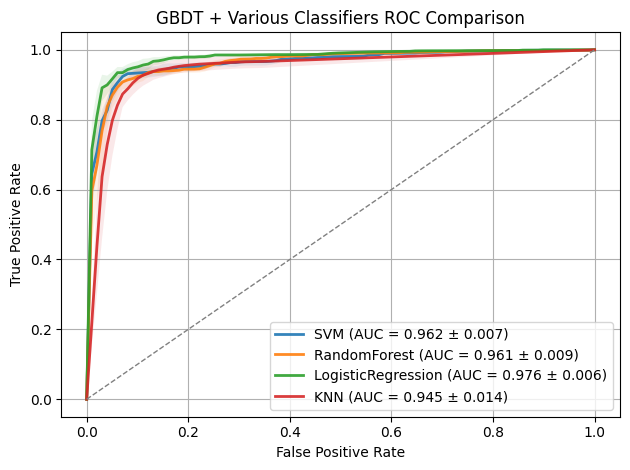

In [ ]:
for name, (clf, param_grid) in classifiers.items():

    print(f" Running GBDT + {name} classifier...")

    pipeline = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('clf', clf)
    ])

    grid = GridSearchCV(pipeline, param_grid, cv=3)
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 100)
    roc_auc_scores = []
    scores = []
    i = 0

    for train_index, test_index in stratified_k_fold.split(selected_data_np, selected_label_np):
        X_train, X_test = selected_data_np[train_index], selected_data_np[test_index]
        y_train, y_test = selected_label_np[train_index], selected_label_np[test_index]

        X_train_trans = OHE.transform(GBDT.apply(X_train)[:, :, 0])
        X_test_trans = OHE.transform(GBDT.apply(X_test)[:, :, 0])

        grid.fit(X_train_trans, y_train)
        predicted_probs = grid.predict_proba(X_test_trans)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, predicted_probs)
        roc_auc = auc(fpr, tpr)


        tprs.append(interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        aucs.append(roc_auc)

        roc_auc_scores.append(roc_auc)
        scores.append(grid.score(X_test_trans, y_test))
        i += 1

        print(f"  Fold {i} : ROC AUC: {roc_auc:.4f} Accuracy: {grid.score(X_test_trans, y_test):.4f}")

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    plt.plot(
        mean_fpr,
        mean_tpr,
        label=f'{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
        lw=2,
        alpha=0.9
    )

    std_tpr = np.std(tprs, axis=0)
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
    plt.fill_between(mean_fpr, tpr_lower, tpr_upper, alpha=0.1)

    print(f"{name} Mean ROC AUC: {mean_auc:.4f}")
    print(f"{name} Mean Accuracy: {np.mean(scores):.4f}")


plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GBDT + Various Classifiers ROC Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
